In [29]:
from pathlib import Path

import numpy as np
from jaxtyping import Float
import polars as pl
import matplotlib.pyplot as plt

# scipy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# muutils
from muutils.jsonlines import jsonl_write, jsonl_load
from muutils.dbg import dbg, dbg_tensor
import muutils.tensor_info
from muutils.tensor_info import array_summary
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True

# attention-motifs
from attention_motifs.bins import Bins

# pl.set_option('display.max_rows', 200)
# pl.set_option('display.max_columns', 200)


In [2]:
# DATA: pl.DataFrame = pl.DataFrame(jsonl_load("../data/scalar_features.jsonl"))

DATA: pl.DataFrame = pl.read_ndjson(Path("../data/scalar_features_fixed.jsonl"))

In [3]:
DATA.head()

feat.markov_transition.time.linreg.intercept,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.median,feat.diag.skewness,feat.markov_transition.time.linreg.slope,feat.markov_transition.time.linreg.r2,feat.markov_transition.diff.mean,feat.diag.std,feat.gram.row.beta_hist.hist.raw.skewness,feat.diag.energy,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.variance,feat.markov_transition.time.entropy,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.col.beta_hist.hist.raw.median,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.first_tok.rms,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.first_tok.psd_total_power,feat.markov_transition.time.psd_total_power,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.gram.row.beta_hist.hist.raw.entropy,feat.diag.autocorr_lag1,feat.markov_transition.time.variance,feat.gram.row.beta_hist.hist.raw.psd_total_power,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.energy,feat.markov_transition.time.kurtosis,…,feat.first_tok.skewness,feat.gram.col.beta_hist.hist.raw.energy,feat.markov_transition.diff.L2_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.diag.psd_total_power,feat.markov_transition.time.L2_norm,feat.log.gram.row.beta_hist.hist.raw.median,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.kurtosis,feat.first_tok.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.diff.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.rms,feat.diag.zero_crossing_rate,feat.diag.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.mean,feat.first_tok.autocorr_lag1,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.L2_norm,feat.markov_transition.time.rms,feat.diag.rms,feat.first_tok.energy,feat.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.time.L1_norm,feat.log.gram.row.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.variance,feat.gram.row.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.markov_transition.env.lower.r2,feat.gram.skew.beta_hist.hist.raw.psd_total_power
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,12.415323,8.855091,1.939376,0.0,0.0,0.00885,0.165037,1.094303,6.369844,5.451335,121.245875,0.563191,0.0,-5.56048,40381.852535,0.0,25.775427,0.931865,317.777149,3.396553,1.896931,16.549212,0.185231,0.029031,0.733353,0.0,16.632153,0.235303,2.32782,0.158451,0.0,6496.91308,111.494417,0.859375,17.271027,null,…,3.412402,283267.602806,0.00885,0.742355,1.596638,0.0,0.0,-0.055552,23.106427,0.235895,0.94515,0.026316,0.756456,0.0,0.104208,0.164973,0.782999,0.02949,0.022139,0.0,0.236381,3.911398,0.644974,0.0,0.163203,5.208675,3.151275,562.813909,30430.265188,-5.94881,1.833027,107.532616,4.743038,0.164973,0.931865,1.0,32258.116126
0.0,25.481297,3.611799,0.99125,0.0,0.0,0.00885,0.283479,4.415902,16.274387,13.658481,123.778461,0.740779,0.0,-5.782257,33086.823867,0.0,26.048842,1.08779,321.176074,5.173941,1.273686,14.92

In [4]:
DATA.describe()

statistic,feat.markov_transition.time.linreg.intercept,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.median,feat.diag.skewness,feat.markov_transition.time.linreg.slope,feat.markov_transition.time.linreg.r2,feat.markov_transition.diff.mean,feat.diag.std,feat.gram.row.beta_hist.hist.raw.skewness,feat.diag.energy,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.variance,feat.markov_transition.time.entropy,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.col.beta_hist.hist.raw.median,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.first_tok.rms,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.first_tok.psd_total_power,feat.markov_transition.time.psd_total_power,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.gram.row.beta_hist.hist.raw.entropy,feat.diag.autocorr_lag1,feat.markov_transition.time.variance,feat.gram.row.beta_hist.hist.raw.psd_total_power,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.energy,…,feat.first_tok.skewness,feat.gram.col.beta_hist.hist.raw.energy,feat.markov_transition.diff.L2_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.diag.psd_total_power,feat.markov_transition.time.L2_norm,feat.log.gram.row.beta_hist.hist.raw.median,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.kurtosis,feat.first_tok.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.diff.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.rms,feat.diag.zero_crossing_rate,feat.diag.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.mean,feat.first_tok.autocorr_lag1,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.L2_norm,feat.markov_transition.time.rms,feat.diag.rms,feat.first_tok.energy,feat.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.time.L1_norm,feat.log.gram.row.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.variance,feat.gram.row.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.markov_transition.env.lower.r2,feat.gram.skew.beta_hist.hist.raw.psd_total_power
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,…,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0,123872.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0

In [50]:
def nan_stats(df: pl.DataFrame) -> pl.DataFrame:
    return df.null_count().transpose(include_header=True, header_name="feature", column_names=["count"]).sort("count", descending=True)

nan_stats(DATA)

feature,count
str,u32
"""feat.markov_transition.time.ku…",123043
"""feat.markov_transition.time.sk…",123043
"""feat.markov_transition.time.li…",0
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.gram.row.beta_hist.hist.r…",0
…,…
"""feat.log.gram.col.beta_hist.hi…",0
"""feat.log.gram.col.beta_hist.hi…",0
"""feat.log.gram.skew.beta_hist.h…",0


In [66]:
def filter_data(df: pl.DataFrame) -> pl.DataFrame:
	"remove cols 'feat.*' which are all nan or have variance 0"
	# remove cols whose names start with "feat." and they have 0 variance
	feat_cols: list[str] = [col for col in df.columns if col.startswith("feat.")]
	remove_cols: list[str] = []
	
	for col in feat_cols:
		# Calculate variance, handling potential NaN values
		var = df.select(pl.col(col).var()).item()
		# print(f"{col = }, {df[col].is_null().sum() = }")
		if var == 0 or df[col].is_null().sum() > 10:
			remove_cols.append(col)

	print(f"Removing {len(remove_cols)}/{len(feat_cols)} cols")
	dbg(remove_cols)
	for col in remove_cols:
		print(f"{col:<60} {array_summary(df[col].to_numpy())}")

	# remove cols that are all nan
	return df.drop(remove_cols)

# because those have nan
DATA_FILTERED: pl.DataFrame = filter_data(DATA)
nan_stats(DATA_FILTERED)

Removing 16/176 cols
feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate      μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=123872 dtype=float64
feat.markov_transition.time.kurtosis                         🚨 NANvals=123043 (99.3%) μ=26.21 σ=36.80 x̃=12.00 R=[-1.91,284.00] shape=123872 dtype=float64
feat.markov_transition.time.zero_crossing_rate               μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=123872 dtype=float64
feat.gram.col.beta_hist.hist.raw.zero_crossing_rate          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=123872 dtype=float64
feat.gram.row.beta_hist.hist.raw.zero_crossing_rate          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=123872 dtype=float64
feat.markov_transition.diff.median                           μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=123872 dtype=float64
feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate     μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=123872 dtype=float64
feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate         μ=0.00 σ=0.00 x̃=0.

[ <ipykernel>:15 -> filter_data ] remove_cols = ['feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.time.kurtosis', 'feat.markov_transition.time.zero_crossing_rate', 'feat.gram.col.beta_hist.hist.raw.zero_crossing_rate', 'feat.gram.row.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.diff.median', 'feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate', 'feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate', 'feat.markov_transition.time.skewness', 'feat.first_tok.zero_crossing_rate', 'feat.log.gram.col.beta_hist.hist.raw.median', 'feat.markov_transition.env.lower.slope', 'feat.markov_transition.env.lower.intercept', 'feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate', 'feat.log.gram.row.beta_hist.hist.raw.median', 'feat.diag.zero_crossing_rate']


feature,count
str,u32
"""feat.markov_transition.time.li…",0
"""feat.gram.col.beta_hist.hist.r…",0
"""feat.gram.row.beta_hist.hist.r…",0
"""feat.diag.skewness""",0
"""feat.markov_transition.time.li…",0
…,…
"""feat.log.gram.col.beta_hist.hi…",0
"""feat.log.gram.col.beta_hist.hi…",0
"""feat.log.gram.skew.beta_hist.h…",0


[ <ipykernel>:21 -> plot_correlation_matrix ] corr_mat: μ=0.02 σ=0.38 x̃=-0.00 R=[-1.00,1.00] ℙ=| ▁▃█▂▁▁| shape=(160,160) dtype=float64


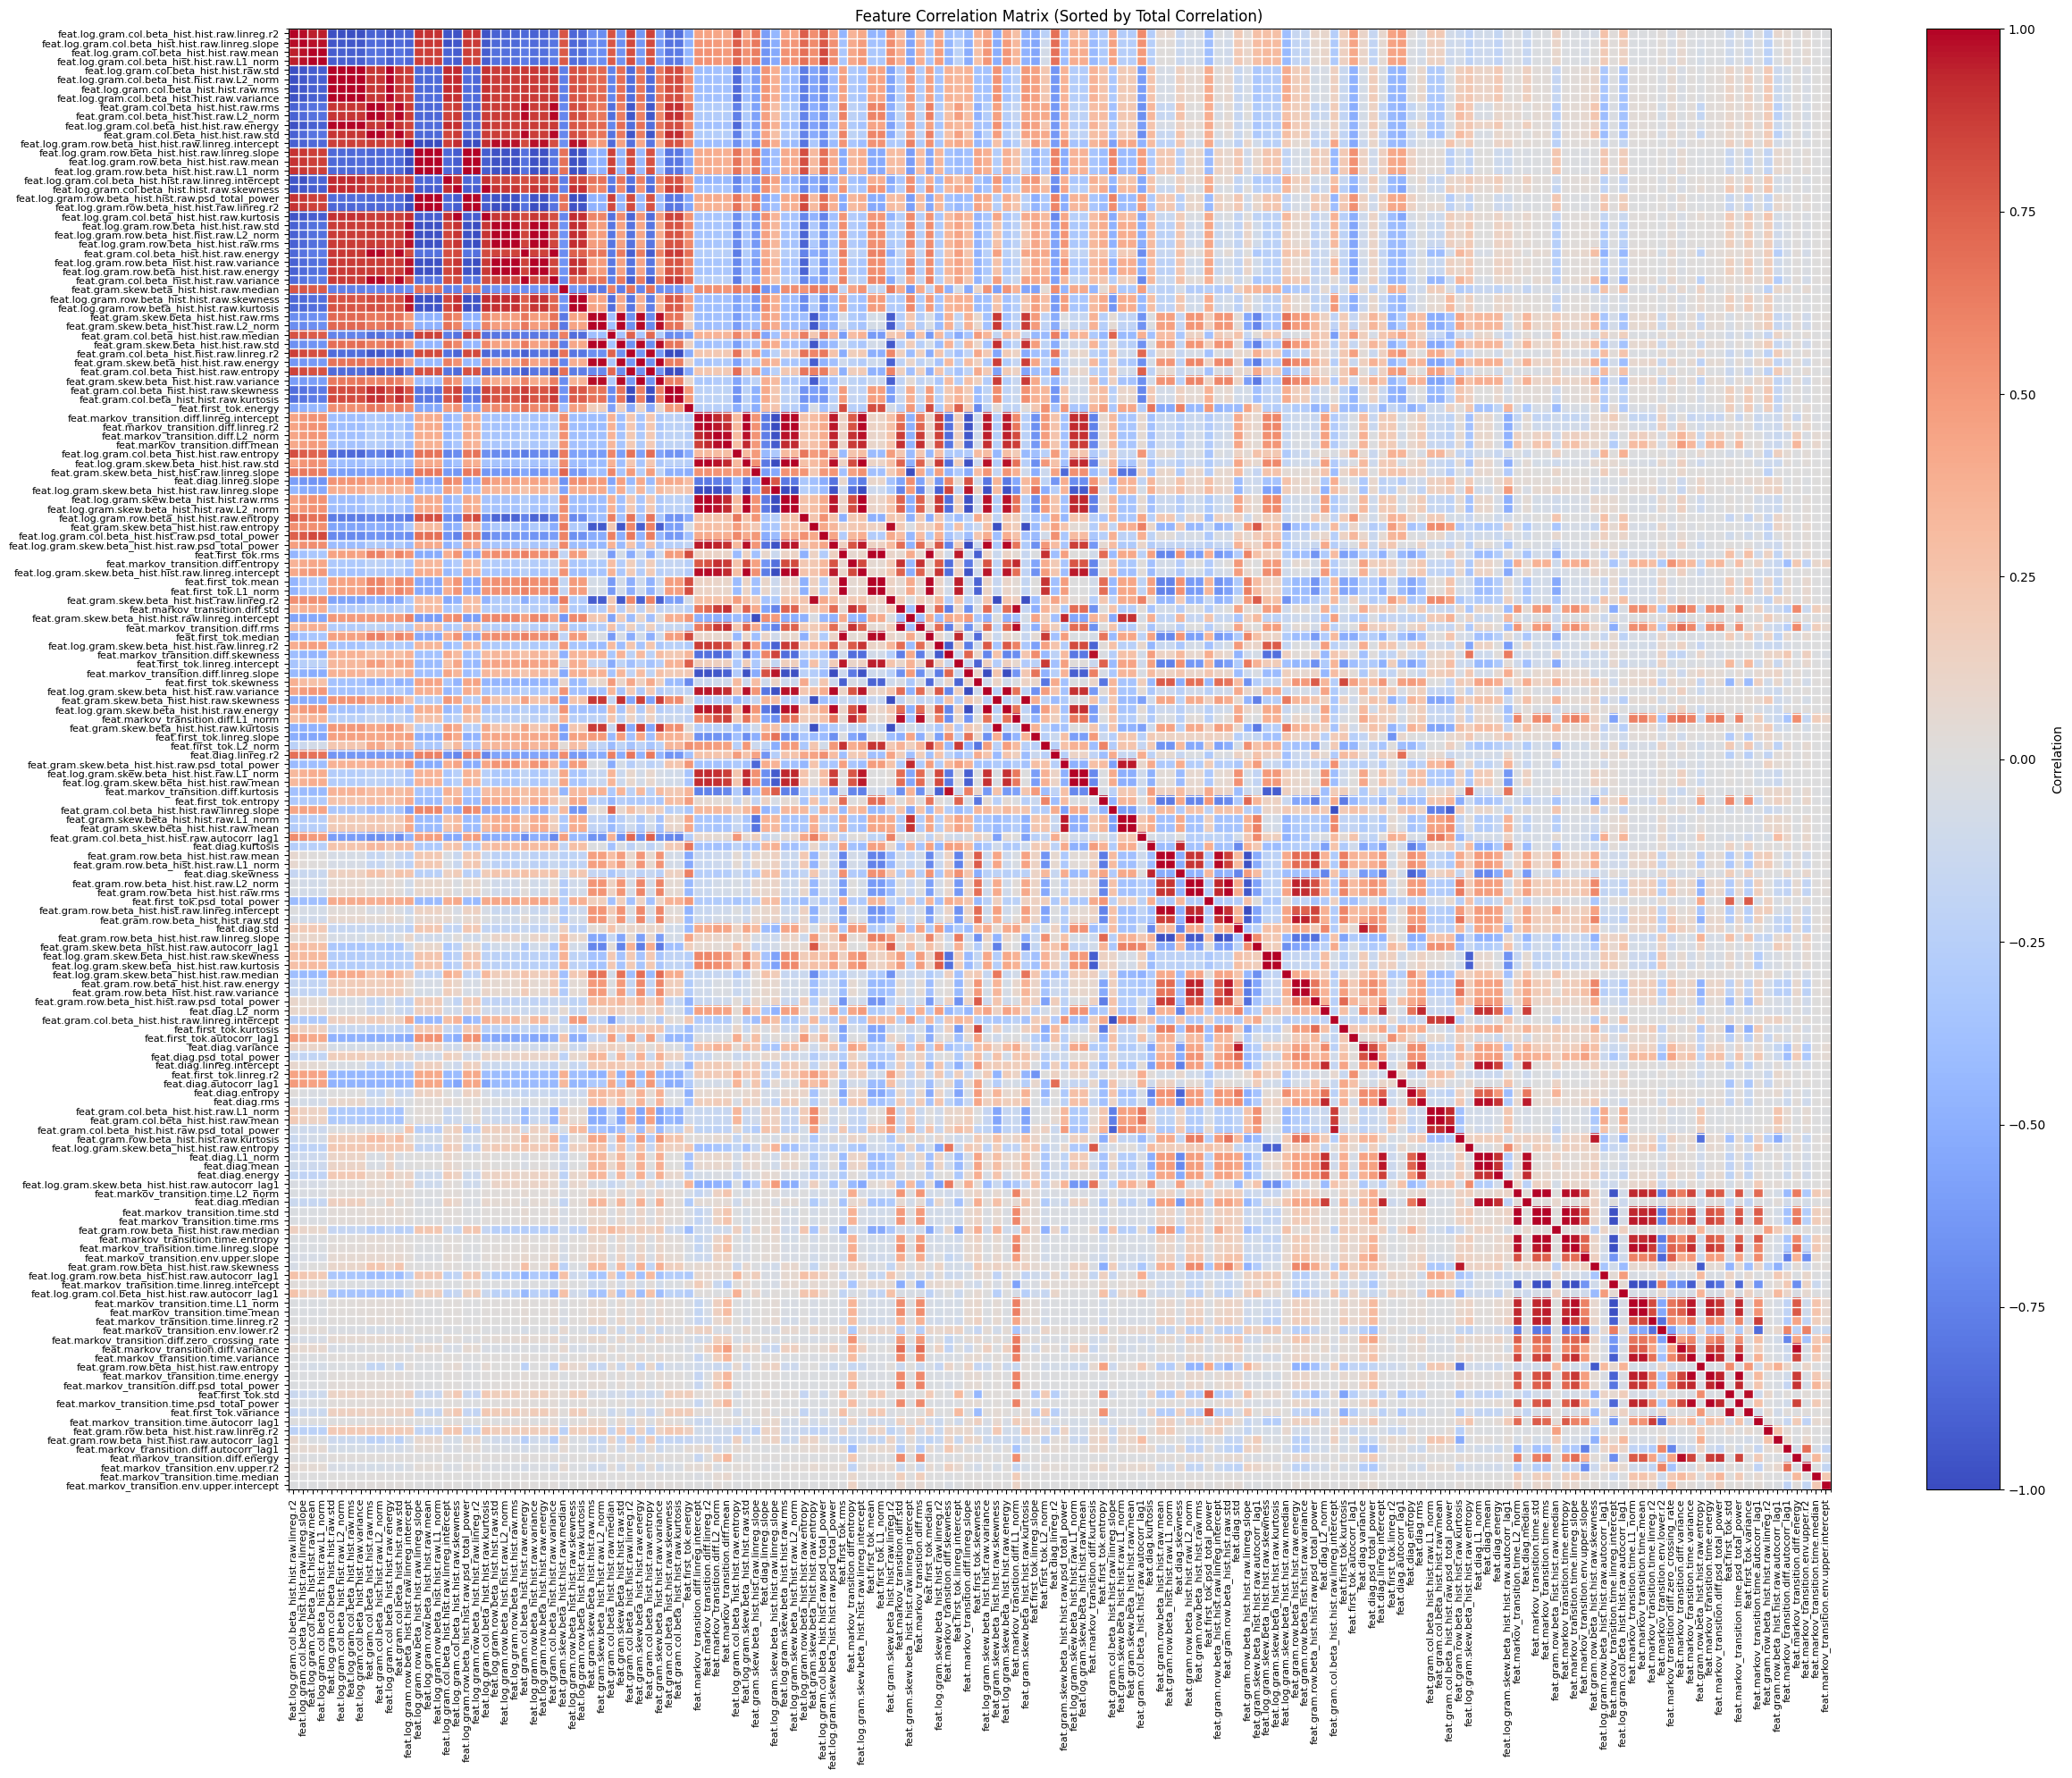

In [70]:
def plot_correlation_matrix(
    df: pl.DataFrame, 
    feature_cols: list[str], 
    sort_by: str = "sum"
) -> None:
    """Plot a correlation matrix of features and identify features with NaN correlations.
    
    # Parameters:
     - `df : pl.DataFrame`
        Input dataframe containing features
     - `feature_cols : list[str]`
        List of feature column names to include in correlation matrix
     - `sort_by : str`
        Sorting method: "sum" (total correlation), "var" (variance), 
        "none" (original order)
        (defaults to `"sum"`)
    """
    # Calculate correlation matrix
    corr_df: pl.DataFrame = df[feature_cols].corr()
    corr_mat: np.ndarray = corr_df.to_numpy()
    dbg_tensor(corr_mat)  # Keep the original debugging call
        
    # Sort features if requested
    if sort_by != "none":
        # Replace NaN with 0 for sorting purposes
        corr_mat_no_nan = np.nan_to_num(corr_mat, nan=0)
        
        if sort_by == "sum":
            # Sort by absolute sum of correlations (total influence)
            sort_metrics = np.abs(corr_mat_no_nan).sum(axis=1)
        elif sort_by == "var":
            # Sort by variance of correlations
            sort_metrics = np.nanvar(corr_mat, axis=1)
        else:
            raise ValueError(f"Unknown sorting method: {sort_by}")
        
        # Get sorting indices (descending order)
        sort_idx = np.argsort(-sort_metrics)
        
        # Reorder matrix and feature names
        corr_mat = corr_mat[sort_idx][:, sort_idx]
        feature_cols = [feature_cols[i] for i in sort_idx]
    
    # Plot with larger figure size
    fig: plt.Figure = plt.figure(figsize=(25, 20))
    ax: plt.Axes = fig.add_subplot(111)
    cax: plt.AxesImage = ax.imshow(corr_mat, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    
    # Add colorbar
    cbar = plt.colorbar(cax)
    cbar.set_label('Correlation')
    
    # Add feature labels
    ax.set_xticks(np.arange(len(feature_cols)))
    ax.set_yticks(np.arange(len(feature_cols)))
    ax.set_xticklabels(feature_cols, rotation=90)
    ax.set_yticklabels(feature_cols)
    
    # Adjust tick parameters for better readability
    plt.setp(ax.get_xticklabels(), fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)
    
    # Add grid lines
    ax.set_xticks(np.arange(-.5, len(feature_cols), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(feature_cols), 1), minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1)
    
    # Set title
    sort_method = {"sum": "Total Correlation", "var": "Correlation Variance", "none": "Original Order"}
    ax.set_title(f"Feature Correlation Matrix (Sorted by {sort_method.get(sort_by, sort_by)})")
    
    plt.tight_layout()
    plt.show()

# Pick feature columns
FEATURE_COLS: list[str] = [col for col in DATA_FILTERED.columns if col.startswith("feat.")]

# Plot correlation matrix
plot_correlation_matrix(DATA_FILTERED, FEATURE_COLS)

In [ ]:
DATA_SCALED: pl.DataFrame = DATA_FILTERED.with_columns([
    ((pl.col(col) - pl.col(col).mean()) / pl.col(col).std()).alias(col)
    for col in FEATURE_COLS
])
DATA_SCALED

# plot_correlation_matrix(DATA_SCALED, FEATURE_COLS)

feat.markov_transition.time.linreg.intercept,feat.gram.col.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.median,feat.diag.skewness,feat.markov_transition.time.linreg.slope,feat.markov_transition.time.linreg.r2,feat.markov_transition.diff.mean,feat.diag.std,feat.gram.row.beta_hist.hist.raw.skewness,feat.diag.energy,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.log.gram.row.beta_hist.hist.raw.variance,feat.markov_transition.time.entropy,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.col.beta_hist.hist.raw.psd_total_power,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.skewness,feat.gram.col.beta_hist.hist.raw.median,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.first_tok.rms,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.first_tok.psd_total_power,feat.markov_transition.time.psd_total_power,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.gram.row.beta_hist.hist.raw.entropy,feat.diag.autocorr_lag1,feat.markov_transition.time.variance,feat.gram.row.beta_hist.hist.raw.psd_total_power,feat.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.row.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.energy,feat.markov_transition.time.median,feat.gram.skew.beta_hist.hist.raw.L2_norm,…,feat.gram.skew.beta_hist.hist.raw.mean,feat.markov_transition.diff.L1_norm,feat.first_tok.skewness,feat.gram.col.beta_hist.hist.raw.energy,feat.markov_transition.diff.L2_norm,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.diag.psd_total_power,feat.markov_transition.time.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.kurtosis,feat.first_tok.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.diff.linreg.r2,feat.log.gram.row.beta_hist.hist.raw.rms,feat.diag.linreg.r2,feat.log.gram.col.beta_hist.hist.raw.mean,feat.first_tok.autocorr_lag1,feat.log.gram.col.beta_hist.hist.raw.linreg.slope,feat.diag.L2_norm,feat.markov_transition.time.rms,feat.diag.rms,feat.first_tok.energy,feat.gram.skew.beta_hist.hist.raw.entropy,feat.markov_transition.time.L1_norm,feat.log.gram.row.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.skewness,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.variance,feat.gram.row.beta_hist.hist.raw.energy,feat.gram.col.beta_hist.hist.raw.linreg.slope,feat.gram.skew.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.std,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.log.gram.skew.beta_hist.hist.raw.mean,feat.markov_transition.env.lower.r2,feat.gram.skew.beta_hist.hist.raw.psd_total_power
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.046632,-0.749063,2.632225,-1.558656,-0.047416,-0.063325,-0.325675,1.119321,-0.47712,0.231379,0.41493,-0.341544,-0.999811,-0.059131,0.267679,0.301629,0.126844,-0.253204,-0.346023,-0.667519,0.492092,-0.347715,-1.193109,-0.427316,-0.680394,-0.018184,-0.915708,-0.712021,0.523354,0.071778,-0.025488,0.099267,0.120382,0.603267,-0.827827,-0.004921,0.120382,…,-0.477578,-0.264389,0.755067,-0.982352,-0.340267,-0.981524,0.497334,-0.060207,0.387923,0.900781,-1.119609,0.850422,-0.327581,-0.971252,0.749242,0.39413,0.749063,0.42943,0.453843,-0.056643,0.688229,-0.909648,-0.698982,-0.038175,0.676402,0.122818,-0.340846,-0.162138,-0.096066,-0.106642,0.041831,0.172524,-0.381292,0.39413,-0.253204,0.081663,-0.601425
0.046632,0.753027,0.67218,-1.869641,-0.047416,-0.063325,-0.325675,4.071554,1.914636,1.171191,1.841583,-0.197974,0.57241,-0.0591

In [78]:

def apply_pca(data: pl.DataFrame, n_components: int, feature_cols: list[str]) -> np.ndarray:
    """Compute PCA."""
    pca: PCA = PCA(n_components=n_components, random_state=0)
    reduced: np.ndarray = pca.fit_transform(data[feature_cols].to_numpy())
    return reduced

# PCA
pca_data: np.ndarray = apply_pca(DATA_SCALED, n_components=5, feature_cols=FEATURE_COLS)

/tmp/ipykernel_18233/4094304571.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20' if len(unique_labels) <= 20 else 'tab20b')


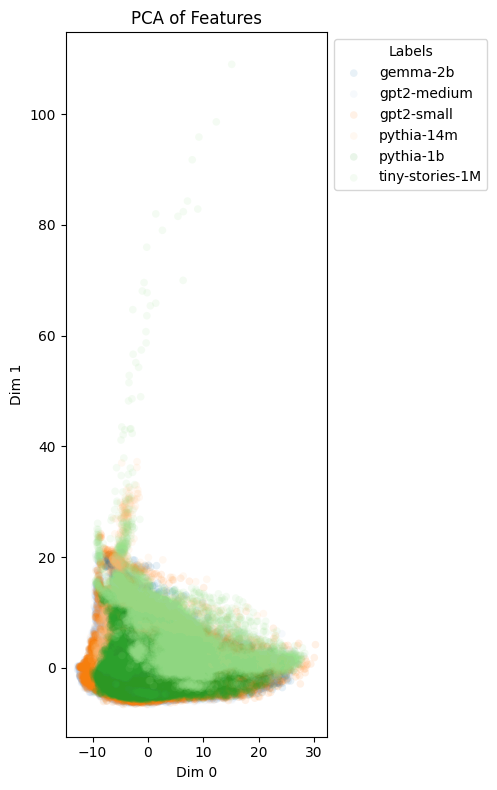

In [88]:
def plot_embedding(embedding: np.ndarray, labels: pl.Series, title: str) -> None:
    """Scatter plot of 2D embedding with points colored by label.
    
    # Parameters:
     - `embedding : np.ndarray`
        2D embedding array with shape (n_samples, 2)
     - `labels : pl.Series`
        Labels for each point
     - `title : str`
        Plot title
    """
    fig: plt.Figure = plt.figure(figsize=(10, 8))
    ax: plt.Axes = fig.add_subplot(111)
    
    # Convert labels to numpy array
    label_values = labels.to_numpy()
    
    # Get unique labels for coloring
    unique_labels = np.unique(label_values)
    
    # Create colormap with enough colors
    cmap = plt.cm.get_cmap('tab20' if len(unique_labels) <= 20 else 'tab20b')
    
    # Plot each label group with a different color
    for i, label in enumerate(unique_labels):
        mask = label_values == label
        sc: plt.PathCollection = ax.scatter(
            embedding[mask, 0], 
            embedding[mask, 1], 
            c=[cmap(i)], 
            label=str(label),
            alpha=0.1,
            s=30,
            edgecolors='none'
        )
    
    # Add legend with label colors
    if len(unique_labels) <= 20:  # Only show legend if not too many labels
        ax.legend(title="Labels", loc="best", markerscale=2)
    
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel("Dim 0")
    ax.set_ylabel("Dim 1")
    # legend outside the plot
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Labels")
    plt.tight_layout()
    plt.show()

plot_embedding(pca_data[:, :2], DATA_SCALED["activation.model"], "PCA of Features")

In [ ]:


def apply_tsne(data: pl.DataFrame, n_components: int = 2, perplexity: float = 30.0) -> np.ndarray:
    """Compute t-SNE."""
    tsne: TSNE = TSNE(n_components=n_components, perplexity=perplexity, random_state=0)
    embedded: np.ndarray = tsne.fit_transform(data)
    return embedded

def cluster_kmeans(data: np.ndarray, n_clusters: int) -> np.ndarray:
    """Cluster with K-Means."""
    kmeans: KMeans = KMeans(n_clusters=n_clusters, random_state=0)
    labels: np.ndarray = kmeans.fit_predict(data)
    return labels


def plot_embedding(embedding: np.ndarray, labels: pl.Series, title: str) -> None:
    """Scatter plot of 2D embedding with label text."""
    fig: plt.Figure = plt.figure()
    ax: plt.Axes = fig.add_subplot(111)
    sc: plt.PathCollection = ax.scatter(embedding[:, 0], embedding[:, 1])
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    # Optionally, overlay text for each point
    # for i, lbl in enumerate(labels):
    #     ax.text(embedding[i, 0], embedding[i, 1], lbl, fontsize=6)
    plt.show()

def main_example(df: pl.DataFrame) -> None:
    
    # t-SNE
    tsne_data: np.ndarray = apply_tsne(df_scaled)
    
    # Clustering
    kmeans_labels: np.ndarray = cluster_kmeans(tsne_data, n_clusters=5)
    
    # Plot PCA embedding
    # (using first two PCA components for a 2D plot)
    plot_embedding(pca_data[:, :2], df["activation.cls"], "PCA of Features")
    
    # Plot t-SNE embedding
    plot_embedding(tsne_data, df["activation.cls"], "t-SNE of Features")
    
    # Plot the clusters on t-SNE
    # (If you prefer numeric cluster labels, you can cast them to string.)
    cluster_series: pl.Series = pl.Series(kmeans_labels, index=df.index, dtype=str)
    plot_embedding(tsne_data, cluster_series, "K-Means Clusters (t-SNE)")


main_example(DATA_NANLESS)